# KOBEsim example

In this tutorial:
- We simulate the RV dataset of a 25 Earth mass planet orbiting a K-dwarf host star with a period of $P = 60.3$ days.
- We run KOBEsim for this dataset to find the **optimal next observing date**.

Let's start with some general imports and set ups

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
import sys

EXAMPLE_DIR = Path.cwd().resolve()
REPO_ROOT = EXAMPLE_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

# dataset name
path_data = "data/mock_rv_25Me_60d.csv"

# constants
cte_G = 6.6743e-11   # m**3/(kg * s**2)
me_to_kg = 5.9722e24 # Mass of the Earth
ms_to_kg = 1.9891e30
d_to_s = 24 * 3600

# periodogram set-up
n_peaks = 1
min_per_d = 3
max_per_d = 160.0

# general
star = 'KOBE-1' # name of the star
BJD_offset = 2_450_000
peak_colors = ["m", "dodgerblue"]

## Simulation

We use a function from KOBEsim module to create the mock dataset.

In [2]:
import modules_KOBEsim.run_MCMC as KOBEsimMod

# random array of observations [BJD - 2450000]
n_obs = 50
timespan = 300
t = np.sort(np.random.uniform(9800., 9800. + timespan, n_obs))

#----- Planet parameters ------#
Vsys = 0  # m/s
P = 60.3  # days
inc = 90  # deg
Mp = 25   # M_Earth
Ms = 0.6  # M_Sun
ecc = 0
w = np.radians(0)
t0 = t[5] + np.random.uniform(0, 1)
#------------------------------#

# units m/s
K = Mp * me_to_kg * np.sin(np.radians(inc)) * (1 - ecc**2)**(-1/2) * (Mp * me_to_kg + Ms * ms_to_kg)**(-2/3) * (2 * np.pi * cte_G / (P * d_to_s))**(1/3)
secosw = np.sqrt(ecc) * np.cos(w)
sesinw = np.sqrt(ecc) * np.sin(w)

# parameters Linear and Quadratic trends
m = 0
q = 0

# units m/s
rv_keplerian = KOBEsimMod.model_RV(Vsys, P, K, t0, secosw, sesinw, m, q, t, planet = True)[0]

We add white noise and simulate associated uncertainties to the mock RV meaurements

In [3]:
mu_noise, std_noise = 0., 3.
mu_erv, std_erv = 3., 0.3

rv_white_noise = np.random.choice([-1, 1], n_obs) * np.random.normal(mu_noise, std_noise, n_obs) # m/s
rv_mock = rv_keplerian + rv_white_noise 

erv_mock = np.abs(np.random.normal(mu_erv, std_erv, n_obs)) # m/s

The CSV file must have the columns `jd`, `rv`, and `erv`.

In [4]:
df_rv_mock = pd.DataFrame({'jd': t,
                           'rv': rv_mock,
                           'erv': erv_mock})

df_rv_mock.to_csv(path_data, index = False)

## Visualize dataset

We select the first observations in chronological order, reproducing the idea of acting when a periodicity begins to emerge.

In [5]:
d = pd.read_csv(path_data)
n_data = 15

data = d.iloc[:n_data].copy()
data.head()

,jd,rv,erv
0,9800.206552,-0.350204,2.944158
1,9801.533370,-4.298429,2.681816
2,9820.026332,2.719798,2.512782
3,9821.540279,7.237588,2.978652
4,9825.101643,1.231240,2.850888


### Generalized Lomb-Scargle (GLS) periodogram

In [6]:
gls = LombScargle(data.jd, data.rv, data.erv)
frequency, power = gls.autopower(
    minimum_frequency = 1 / max_per_d,
    maximum_frequency = 1 / min_per_d)
period = 1 / frequency
fap_10, fap_05, fap_01 = gls.false_alarm_level([0.10, 0.05, 0.01])

peaks, _ = find_peaks(power, height = 0.4 * fap_10)
peaks = peaks[np.argsort(power[peaks])[::-1]]
if len(peaks) == 0:
    raise RuntimeError("No periodogram peaks passed the threshold.")

candidate_period_days = period[peaks[0]]
print(f"Dominant candidate period: {candidate_period_days:.2f} d")

Dominant candidate period: 51.73 d


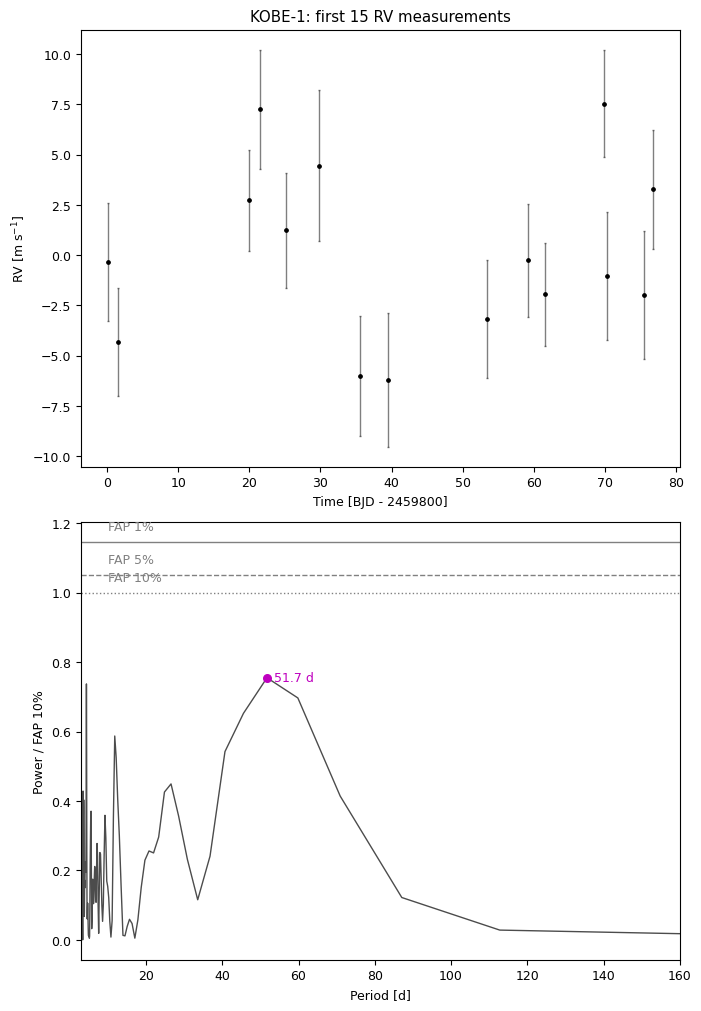

In [7]:
fig, (ax_rv, ax_gls) = plt.subplots(2, 1, figsize = (6.9, 10), constrained_layout = True)

time_zero = int(np.floor(data.jd.min()))
ax_rv.errorbar(
    data.jd - time_zero, data.rv, yerr = data.erv, color = "k", linestyle = "none",
    alpha = 0.5, capsize = 1, linewidth = 1)
ax_rv.scatter(data.jd - time_zero, data.rv, color = "k", edgecolor = "w", lw = 1, s = 20)
ax_rv.set(xlabel = f"Time [BJD - {time_zero + BJD_offset}]",
          ylabel = "RV [m s$^{-1}$]",
          title = f"{star}: first {len(data.rv)} RV measurements")

ax_gls.plot(period, power / fap_10, color = "k", lw = 1, alpha = 0.7)
for level, label, linestyle in [(fap_10, "FAP 10%", ":"), (fap_05, "FAP 5%", "--"), (fap_01, "FAP 1%", "-")]:
    normalized_level = level / fap_10
    ax_gls.axhline(normalized_level, color = "grey", lw = 1, ls = linestyle)
    ax_gls.text(10, normalized_level + 0.025, label, color = "grey", fontsize = 9, va = "bottom")

for index, peak in enumerate(peaks[:n_peaks]):
    color = peak_colors[index % len(peak_colors)]
    peak_period = period[peak]
    peak_power = power[peak] / fap_10
    ax_gls.scatter(peak_period, peak_power, color = color, s = 30, zorder = 3)
    ax_gls.annotate(f"{peak_period:.1f} d", (peak_period, peak_power), xytext = (5, 0),
                    textcoords = "offset points", color = color, fontsize = 9, va = "center")

ax_gls.set(xlim = (min_per_d, max_per_d), xlabel = "Period [d]", ylabel = "Power / FAP 10%")
plt.show()

In [8]:
# save sub-dataset to use later
data.to_csv(f'data/mock_rv_20Me_60d_first{n_data}.csv', index = 0)

## Running KOBEsim! 

The period above is the candidate that will be passed to KOBEsim (TARGET PERIOD).

### From the terminal

The following notebook cell executes the same command that can be run from
the repository root in a terminal using Python 3.10 or later:

```bash
python run_KOBEsim.py -obs 37.223 -2.546 2168 -star "KOBE-1" -file "example/data/mock_rv_20Me_60d_first20.csv" -P 51.7 -Nph 15 -max_da 100 -n 5000
```
> Note that in this example we provided the coordinates for the CAHA observatory (`-obs`), compare 15 different possible future orbital phases (`-Nph`), do not allow to observe further than 100 days apart from now (`-max_da`).

### Let's make it executable from Jupyter

In [9]:
import subprocess
import sys

EXAMPLE_DIR = Path.cwd().resolve()
REPO_ROOT = EXAMPLE_DIR.parent
assert (REPO_ROOT / "run_KOBEsim.py").exists()

rv_file = REPO_ROOT / "example" / "data" / f"mock_rv_20Me_60d_first{n_data}.csv"

In [10]:
command = [
    sys.executable,
    "run_KOBEsim.py",
    "-obs", "37.223", "-2.546", "2168",
    "-star", "KOBE-1",
    "-file", str(rv_file),
    "-P", "51.7",
    "-Nph", "15",
    "-max_da", "100",
    "-n", "5000"
]

subprocess.run(command, cwd = REPO_ROOT, check = False)

Fit H0 and H1 models for KOBE-1 data


100%|██████████| 2500/2500 [00:00<00:00, 4151.66it/s]


Initial ln(B01) = -5.651 +- 0.175
KOBE-1: resolving target coordinates with SIMBAD...
KOBE-1: searching observable dates for up to 100.0 days and 15 orbital phases...
KOBE-1: visibility search — day 0/100, phases found: 0/15
KOBE-1: visibility search — day 10/100, phases found: 3/15
KOBE-1: visibility search — day 20/100, phases found: 6/15
KOBE-1: visibility search — day 30/100, phases found: 9/15
KOBE-1: visibility search — day 40/100, phases found: 12/15
KOBE-1: visibility search completed — 15/15 phases found.
KOBE-1: KOBEsim testing orbital phase 1/15


100%|██████████| 2500/2500 [00:00<00:00, 4299.21it/s]


KOBE-1: KOBEsim testing orbital phase 2/15


...

100%|██████████| 2500/2500 [00:00<00:00, 4274.35it/s]


KOBE-1: KOBEsim testing orbital phase 15/15


100%|██████████| 2500/2500 [00:00<00:00, 4268.83it/s]


TARGET KOBE-1
-------------------------
Optimum phase = 0.879
Optimum next observing date around 2461295.328 JD -> 2026-09-11
Predicted Deltaln(B01) = 0.041 +- 0.244
Predicted ln(B01) = -5.61 +- 0.17


CompletedProcess(args=['/Users/obalsalobre/troy_env/bin/python', 'run_KOBEsim.py', '-obs', '37.223', '-2.546', '2168', '-star', 'KOBE-1', '-file', '/Users/obalsalobre/Desktop/dirs/work/projects/kobe/kobesim/code/github/KOBEsim-main_github/example/data/mock_rv_20Me_60d_first15.csv', '-P', '51.7', '-Nph', '15', '-max_da', '100', '-n', '5000'], returncode=0)

## KOBEsim outputs

KOBEsim saves the candidate-date table and associated figures in the output
directory.

In [11]:
import pymupdf # run "pip install pymupdf" if not installed
import fitz
from IPython.display import FileLink, IFrame, Markdown, display, Image

OUT_ROOT = REPO_ROOT / "outputs"

figure_dir = next(
    (
        directory
        for directory in [OUT_ROOT / "figures", OUT_ROOT / "Figures"]
        if directory.exists()
    ),
    None,
)

table_dir = next(
    (
        directory
        for directory in [OUT_ROOT / "tables", OUT_ROOT / "Files"]
        if directory.exists()
    ),
    None,
)

#### kobe-1_nobs-15_wh-false_bayes-factor-by-phase.pdf

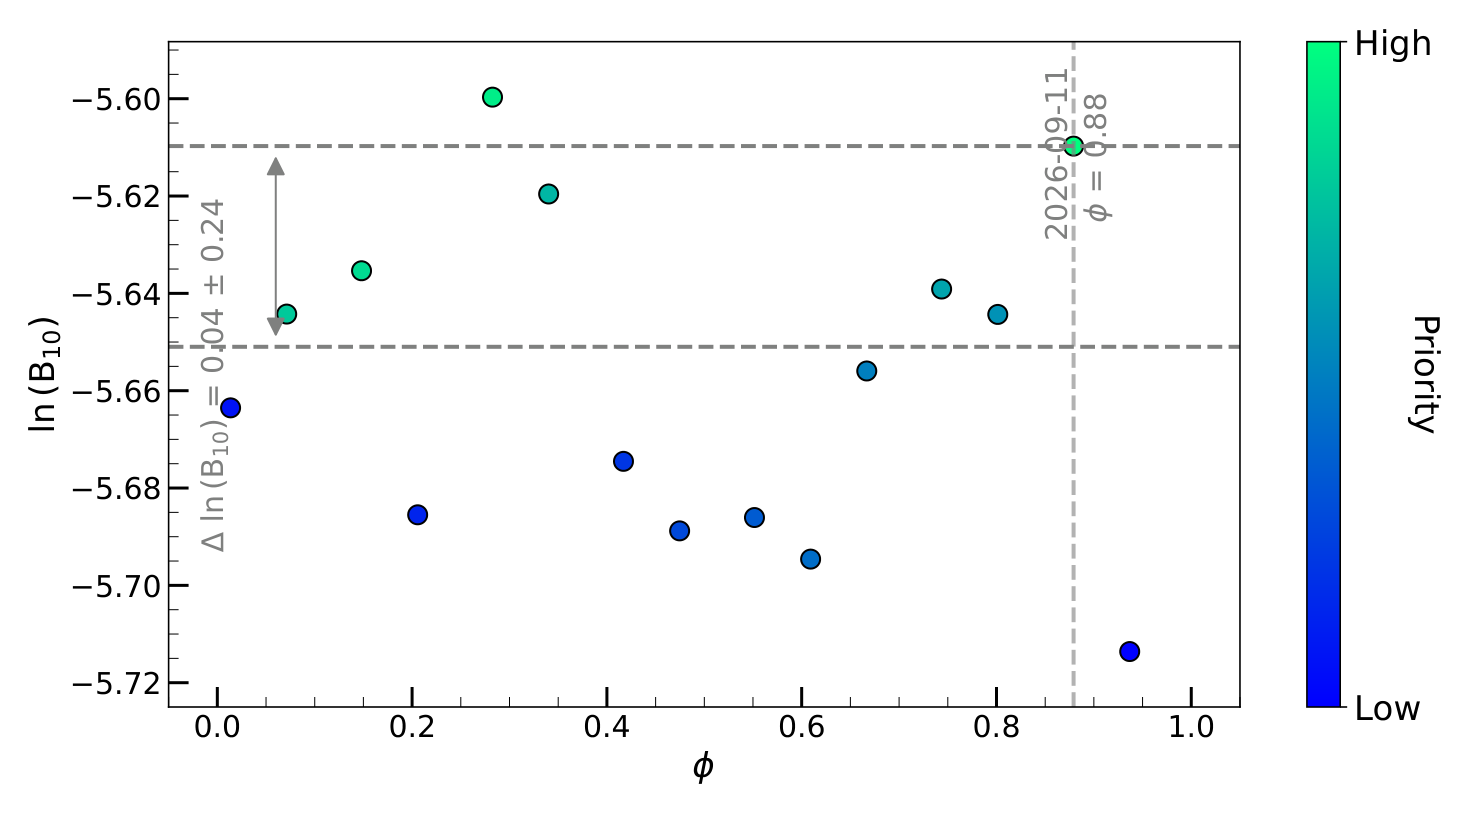

#### kobe-1_nobs-15_wh-false_posterior-corner.pdf

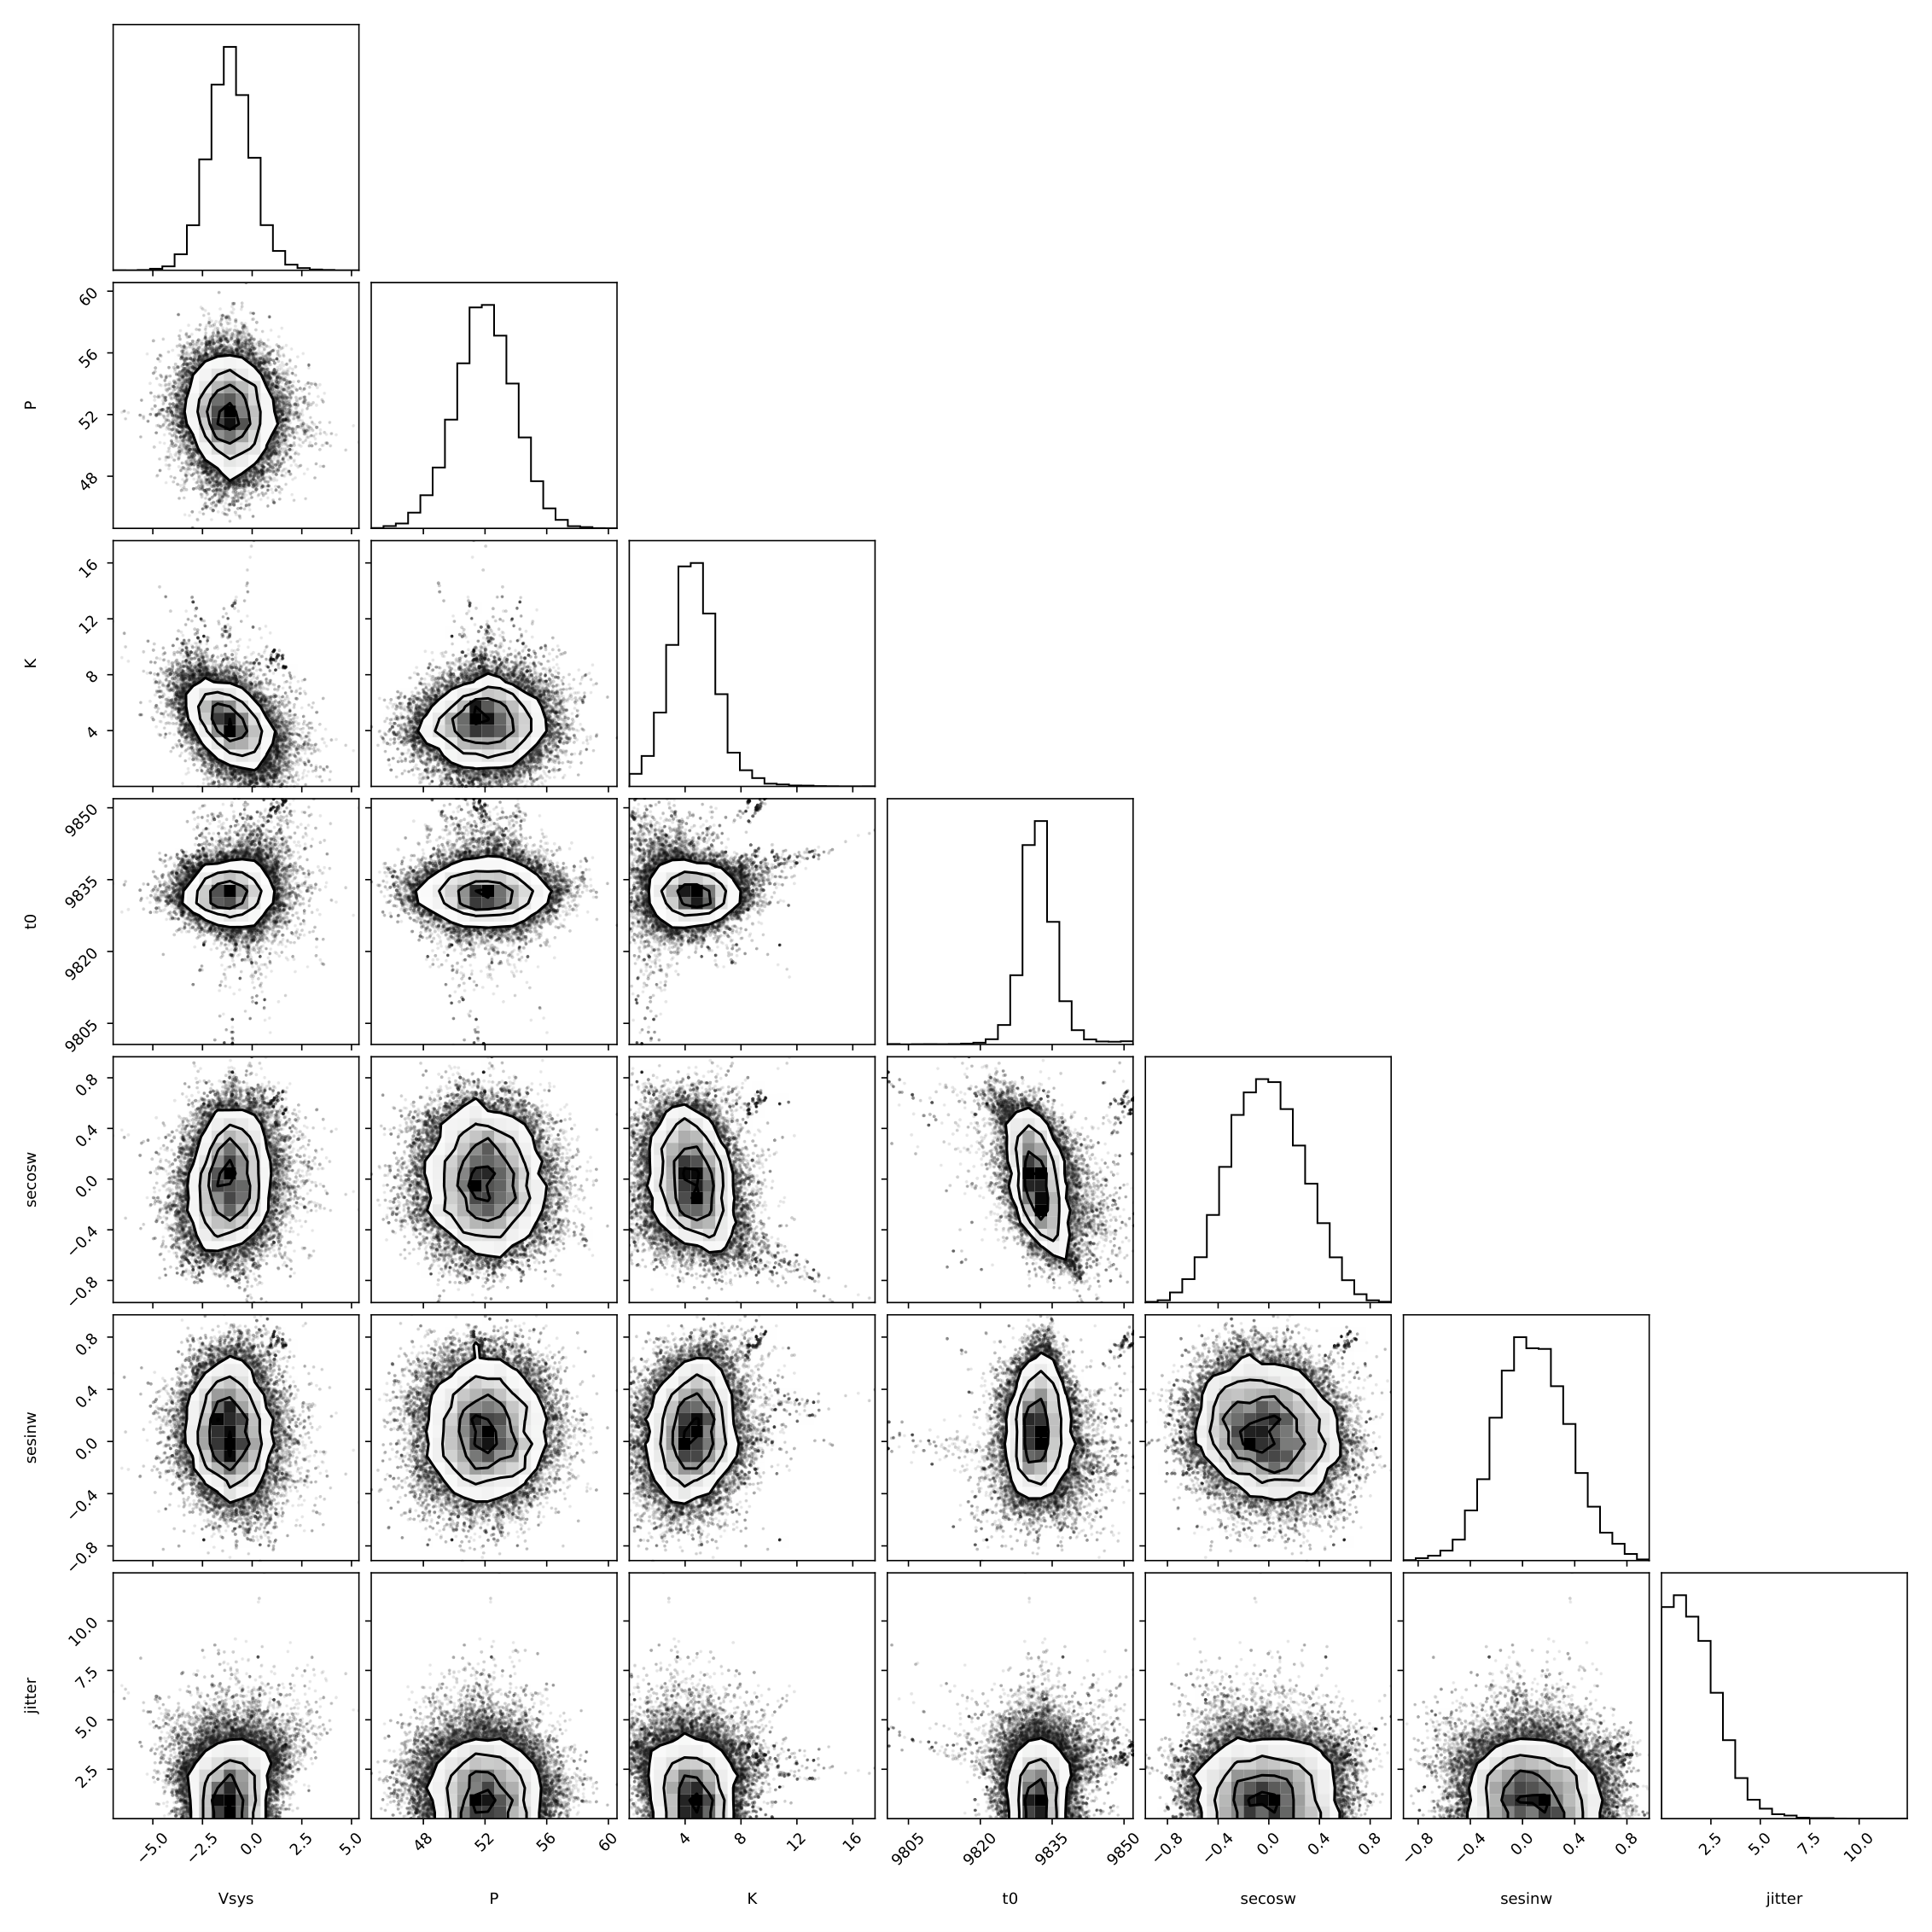

#### kobe-1_nobs-15_wh-false_rv-fit.pdf

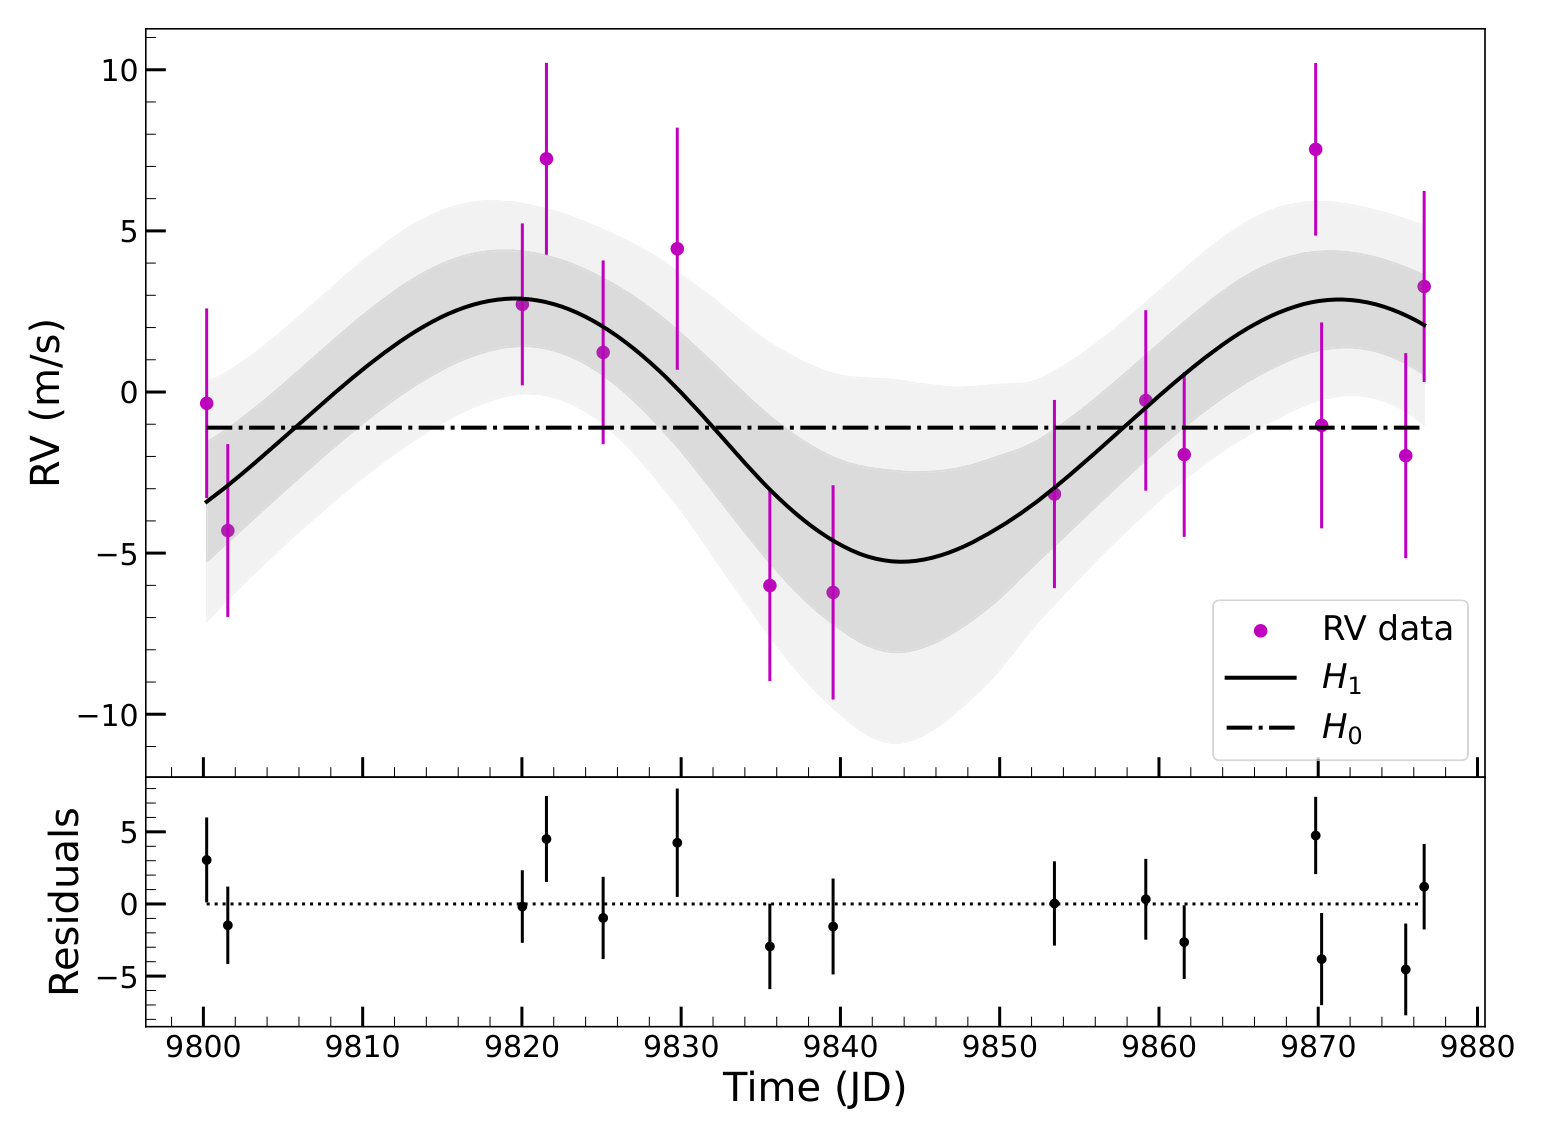

In [12]:
if figure_dir is None:
    raise FileNotFoundError("No figure directory was created by KOBEsim.")

figure_files = sorted(
    figure_dir.glob("*.pdf"),
    key = lambda path: path.stat().st_mtime,
    reverse = True,
)

if not figure_files:
    raise FileNotFoundError("No PDF figures were found.")

for figure_file in figure_files[:3]:
    display(Markdown(f"#### {figure_file.name}"))
    pdf = fitz.open(figure_file)
    page = pdf[0]
    pix = page.get_pixmap(matrix = fitz.Matrix(2, 2))
    display(Image(data = pix.tobytes("png")))
    pdf.close()